In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, spearmanr, norm
from statsmodels.stats.multitest import multipletests

writing = False  # set True to save the forest plot to disk

variant_table_path = "data/2602_combined_variant_info_80k_tested_NGN2_tfbs_h13_remap2022.tsv.gz"
forest_plot_dir = "data/variant_enrichment_plot"

NGN2_variants_with_gwas_tested = pd.read_csv(variant_table_path, sep="\t", low_memory=False)
print(f"Loaded {len(NGN2_variants_with_gwas_tested):,} variants, {NGN2_variants_with_gwas_tested.shape[1]} columns")

Loaded 38,968 variants, 204 columns


In [ ]:
# Each entry maps a human-readable support label to the underlying column(s)
# that indicate "this variant has this kind of independent support". Several
# candidate bins (heart cCRE, cardiac E2G, various GTEx/UKBB variants) were
# tried and left out because those columns weren't reliably informative for
# this analysis - kept here commented for provenance, matching the original notebook.
SUPPORT_BINS = {
    "SCREEN brain cCRE": ["is_brain_SCREEN_cCRE"],
    # "SCREEN heart cCRE": ["is_heart_SCREEN_cCRE"],
    "SCREEN H1 cCRE": ["is_H1_SCREEN_cCRE"],
    "Brain E2G link": ["brain_e2g_score"],
    # "Cardiac E2G link": ["cardiac_e2g_score"],
    "GTEx brain high-conf eQTL": ["GTEx_brain_high_confidence"],
    "HOCOMOCOv13 TFBS": ["local_bitscore_has_H13_motif_bitscore"],
    "ReMap2022 TFBS": ["has_remap2022_TFBS_overlap"],
    "GWAS any trait": ["GWAS_PUBMEDID"],
}


def _to_bool_series(df: pd.DataFrame, cols):
    """
    Turn one or more columns into a single boolean 'support present' series.
    Rules:
      - boolean columns: True stays True
      - numeric columns: >0 is True
      - string/object columns: non-empty & notna is True
      - multiple columns: any-of is True
    """
    if isinstance(cols, str):
        cols = [cols]

    present = pd.Series(False, index=df.index)

    for c in cols:
        if c not in df.columns:
            raise KeyError(f"Column not found: {c}")

        s = df[c]

        if pd.api.types.is_bool_dtype(s):
            cur = s.fillna(False)
        elif pd.api.types.is_numeric_dtype(s):
            cur = s.fillna(0) > 0
        else:
            cur = s.notna() & (s.astype(str).str.strip() != "") & (s.astype(str) != "nan")

        present = present | cur

    return present


def fisher_for_bin(df, support_bool, sig_col="NGN2_variant_is_significant", alternative="greater"):
    """
    2x2 Fisher exact test: support present vs absent, significant vs not
    significant. One-sided ("greater") since the hypothesis is that support
    is enriched among significant variants, not merely associated.
    """
    sig = df[sig_col].astype(bool)

    a = int((support_bool & sig).sum())
    b = int((support_bool & ~sig).sum())
    c = int((~support_bool & sig).sum())
    d = int((~support_bool & ~sig).sum())

    table = np.array([[a, b], [c, d]])
    oddsratio, pval = fisher_exact(table, alternative=alternative)

    return {
        "a_support_sig": a,
        "b_support_nonsig": b,
        "c_nosupport_sig": c,
        "d_nosupport_nonsig": d,
        "odds_ratio": oddsratio,
        "p_value": pval,
        "table": table,
    }


def or_ci_log_method(a, b, c, d, alpha=0.05):
    """
    Approx (1-alpha) CI for OR via log(OR) +/- z*SE using Haldane-Anscombe
    correction to avoid zero cells. `z` is derived from `alpha`.
    """
    a2, b2, c2, d2 = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    or_ = (a2 * d2) / (b2 * c2)
    se = np.sqrt(1 / a2 + 1 / b2 + 1 / c2 + 1 / d2)
    z = norm.ppf(1 - alpha / 2)
    lo = np.exp(np.log(or_) - z * se)
    hi = np.exp(np.log(or_) + z * se)
    return float(or_), float(lo), float(hi)


def forest_plot(df_res, use_corrected_or=True, title="Enrichment in significant variants"):
    """Log2(OR) forest plot with asymmetric 95% CI error bars, point size
    scaled by the number of significant variants carrying that support type,
    and per-row FDR annotation. Kept verbatim from the original analysis so
    the figure looks identical to the published version."""
    or_col = "odds_ratio_HA" if use_corrected_or else "odds_ratio"

    d = df_res.copy()
    d = d.sort_values("fdr_bh", ascending=False).reset_index(drop=True)

    y = np.arange(len(d))

    ors = d[or_col].astype(float).values
    lo = d["ci95_lo"].astype(float).values
    hi = d["ci95_hi"].astype(float).values

    x = np.log2(ors)
    xerr = np.vstack([np.log2(ors) - np.log2(lo), np.log2(hi) - np.log2(ors)])

    sizes = d["sig_with_support"].astype(float).values
    s = 30 + 8 * np.sqrt(np.maximum(sizes, 0))

    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.45 * len(d))))

    ax.errorbar(x, y, xerr=xerr, fmt="o", ms=0, lw=1)
    ax.scatter(x, y, s=s)

    ax.axvline(0, linestyle="--")
    ax.set_yticks(y)
    ax.set_yticklabels(d["support_bin"])
    ax.set_xlabel("log2(Odds Ratio)")
    ax.set_title(title)

    for i, fdr in enumerate(d["fdr_bh"].values):
        if fdr < 0.01:
            ax.text(ax.get_xlim()[1], i, f"  FDR={fdr:.1e}", va="center")
        else:
            ax.text(ax.get_xlim()[1], i, f"  FDR={fdr:.2f}", va="center")
    plt.tight_layout()
    return fig, ax

In [3]:
df = NGN2_variants_with_gwas_tested.copy()

if "NGN2_variant_has_readout" in df.columns:
    df = df[df["NGN2_variant_has_readout"].astype(bool)].copy()

sig_col = "NGN2_variant_is_significant"
df[sig_col] = df[sig_col].astype(bool)

results = []
for bin_name, cols in SUPPORT_BINS.items():
    support = _to_bool_series(df, cols)

    n_all = int(len(df))
    n_sig = int(df[sig_col].sum())

    all_with = int(support.sum())
    sig_with = int((support & df[sig_col]).sum())

    prop_all = all_with / n_all if n_all else np.nan
    prop_sig = sig_with / n_sig if n_sig else np.nan

    ft = fisher_for_bin(df, support, sig_col=sig_col, alternative="greater")
    or_corr, ci_lo, ci_hi = or_ci_log_method(
        ft["a_support_sig"], ft["b_support_nonsig"],
        ft["c_nosupport_sig"], ft["d_nosupport_nonsig"],
    )

    results.append({
        "support_bin": bin_name,
        "n_all": n_all,
        "n_sig": n_sig,
        "all_with_support": all_with,
        "sig_with_support": sig_with,
        "prop_all_with_support": prop_all,
        "prop_sig_with_support": prop_sig,
        "odds_ratio": ft["odds_ratio"],
        "odds_ratio_HA": or_corr,
        "ci95_lo": ci_lo,
        "ci95_hi": ci_hi,
        "p_value": ft["p_value"],
    })

res = pd.DataFrame(results)
res["fdr_bh"] = multipletests(res["p_value"].values, method="fdr_bh")[1]
res["enriched_fdr_0.05"] = res["fdr_bh"] < 0.05
res = res.sort_values(["fdr_bh", "p_value", "odds_ratio_HA"], ascending=[True, True, False]).reset_index(drop=True)

short_table = res[[
    "support_bin",
    "all_with_support", "n_all", "prop_all_with_support",
    "sig_with_support", "n_sig", "prop_sig_with_support",
    "odds_ratio_HA", "ci95_lo", "ci95_hi",
    "p_value", "fdr_bh",
]]

fmt = short_table.copy()
fmt["prop_all_with_support"] = (fmt["prop_all_with_support"] * 100).round(2)
fmt["prop_sig_with_support"] = (fmt["prop_sig_with_support"] * 100).round(2)
fmt["odds_ratio_HA"] = fmt["odds_ratio_HA"].round(2)
fmt["ci95_lo"] = fmt["ci95_lo"].round(2)
fmt["ci95_hi"] = fmt["ci95_hi"].round(2)
fmt["p_value"] = fmt["p_value"].apply(lambda x: f"{x:.2e}")
fmt["fdr_bh"] = fmt["fdr_bh"].apply(lambda x: f"{x:.2e}")

fmt_sorted = fmt.sort_values("odds_ratio_HA", ascending=False).reset_index(drop=True)
print(fmt_sorted.to_string(index=False))

              support_bin  all_with_support  n_all  prop_all_with_support  sig_with_support  n_sig  prop_sig_with_support  odds_ratio_HA  ci95_lo  ci95_hi  p_value   fdr_bh
           SCREEN H1 cCRE              1566  38968                   4.02                56   1018                   5.50           1.42     1.08     1.86 1.17e-02 4.09e-02
        SCREEN brain cCRE             13385  38968                  34.35               412   1018                  40.47           1.31     1.15     1.49 2.17e-05 1.52e-04
         HOCOMOCOv13 TFBS             36345  38968                  93.27               965   1018                  94.79           1.31     0.99     1.73 2.53e-02 5.89e-02
           Brain E2G link              7399  38968                  18.99               213   1018                  20.92           1.13     0.97     1.32 6.12e-02 1.07e-01
           ReMap2022 TFBS             14377  38968                  36.89               387   1018                  38.02           1.0

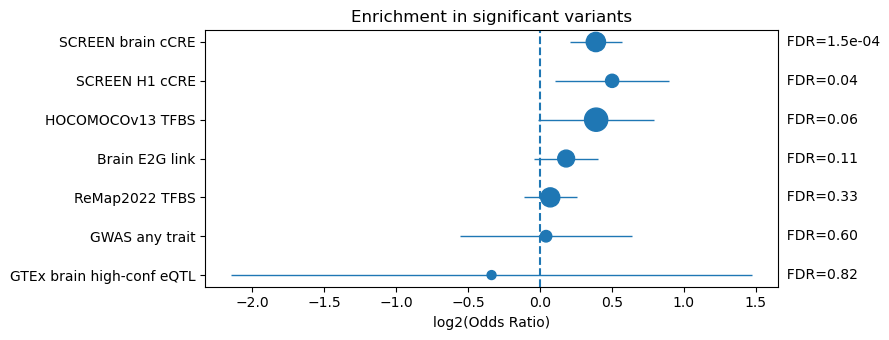

Saved forest plot to data/variant_enrichment_plot


In [4]:
fig, ax = forest_plot(res, use_corrected_or=True)
plt.show()

if writing:
    import os
    os.makedirs(forest_plot_dir, exist_ok=True)
    fig.savefig(f"{forest_plot_dir}/variant_support_enrichment_forest_plot.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{forest_plot_dir}/variant_support_enrichment_forest_plot.svg", bbox_inches="tight")
    print(f"Saved forest plot to {forest_plot_dir}")
else:
    print(f"writing=False - forest plot not saved to {forest_plot_dir}")

### Combined bins: does significance rate increase with the number of independent support types a variant has?

In [5]:
df = NGN2_variants_with_gwas_tested.copy()
df = df[df["NGN2_variant_has_readout"].astype(bool)].copy()
df["NGN2_variant_is_significant"] = df["NGN2_variant_is_significant"].astype(bool)

support_cols = {}
for bin_name, cols in SUPPORT_BINS.items():
    support_cols[bin_name] = _to_bool_series(df, cols)

support_df = pd.DataFrame(support_cols, index=df.index)
support_df["n_supports"] = support_df.sum(axis=1)

summary = (
    df.assign(n_supports=support_df["n_supports"])
    .groupby("n_supports")["NGN2_variant_is_significant"]
    .agg(n_variants="count", n_significant="sum", prop_significant="mean")
    .reset_index()
)
summary["prop_significant"] *= 100
print(summary.to_string(index=False))

 n_supports  n_variants  n_significant  prop_significant
          0        1195             24          2.008368
          1       16106            394          2.446293
          2       11615            293          2.522600
          3        6121            175          2.859010
          4        3308            108          3.264813
          5         606             23          3.795380
          6          16              1          6.250000
          7           1              0          0.000000


In [6]:
rows = []
for k in sorted(summary["n_supports"].unique()):
    mask = support_df["n_supports"] == k

    a = int((mask & df["NGN2_variant_is_significant"]).sum())
    b = int((mask & ~df["NGN2_variant_is_significant"]).sum())
    c = int((~mask & df["NGN2_variant_is_significant"]).sum())
    d = int((~mask & ~df["NGN2_variant_is_significant"]).sum())

    or_, p = fisher_exact([[a, b], [c, d]], alternative="greater")
    or_ha, lo, hi = or_ci_log_method(a, b, c, d)

    rows.append({
        "n_supports": k,
        "n_variants": int(mask.sum()),
        "sig_variants": a,
        "odds_ratio_HA": or_ha,
        "ci95_lo": lo,
        "ci95_hi": hi,
        "p_value": p,
    })

support_count_enrich = pd.DataFrame(rows)
support_count_enrich["fdr_bh"] = multipletests(support_count_enrich["p_value"], method="fdr_bh")[1]
print(support_count_enrich.to_string(index=False))

rho, p_trend = spearmanr(summary["n_supports"], summary["prop_significant"])
print(f"\nSpearman trend (n_supports vs. proportion significant): rho={rho:.3f}, p={p_trend:.2e}")

 n_supports  n_variants  sig_variants  odds_ratio_HA  ci95_lo    ci95_hi  p_value   fdr_bh
          0        1195            24       0.773437 0.515855   1.159638 0.927135 1.000000
          1       16106           394       0.894077 0.786896   1.015856 0.960943 1.000000
          2       11615           293       0.951426 0.829319   1.091512 0.775483 1.000000
          3        6121           175       1.119803 0.949520   1.320624 0.102330 0.272879
          4        3308           108       1.293877 1.056878   1.584022 0.009686 0.077490
          5         606            23       1.511749 0.996128   2.294269 0.049450 0.197798
          6          16             1       3.608037 0.674393  19.303183 0.345330 0.690659
          7           1             0      12.420062 0.505656 305.065295 1.000000 1.000000

Spearman trend (n_supports vs. proportion significant): rho=0.333, p=4.20e-01
